## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split


## DEFINITION OF VARIABLES

In [2]:
SOURCE_POLYMER_FILE = 'all_spectra.csv'
SOURCE_MICROPLASTIC_FILE = 'ambient_spectra.csv'

## Affine Coupling Layer

In [3]:
class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim = 64):
        super().__init__()
        self.dim = dim
        self.split_dim = dim // 2

        self.scale_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim,hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim)),
            nn.Tanh()
        )

        self.shift_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim,hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim))
        )

    def forward(self, x):
        x1,x2 = x[:,:self.split_dim], x[:,self.split_dim:]

        s = self.scale_net(x1)
        s = s * 0.3
        t = self.shift_net(x1)

        y1 = x1
        y2 = x2 * torch.exp(s) + t

        log_det = s.sum(dim = 1)

        return torch.cat([y1, y2], dim=1), log_det
    
    def inverse(self, y):
        y1, y2 = y[:, :self.split_dim], y[:, self.split_dim:]

        s = self.scale_net(y1)
        s = s * 0.3
        t = self.shift_net(y1)

        x1 = y1
        x2 = (y2 - t) * torch.exp(-s)

        return torch.cat([x1, x2], dim=1)

In [4]:
class StandardGaussian:
    def __init__(self, dim):
        self.dim = dim
        self.distribution = torch.distributions.MultivariateNormal(
            torch.zeros(dim),
            torch.eye(dim)
        )

    def log_prob(self, z):
        return self.distribution.log_prob(z)
    
    def sample(self, n_samples):
        return self.distribution.sample((n_samples,))


In [5]:
class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.register_buffer('permutation', torch.randperm(dim))
        self.register_buffer('inverse_permutation', torch.argsort(self.permutation))

    def forward(self, x):
        return x[:, self.permutation], torch.zeros(x.shape[0], device=x.device)
    
    def inverse(self, y):
        return y[:,self.inverse_permutation]
    

In [6]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim, n_layers = 4, hidden_dim = 64):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.base_dist = StandardGaussian(dim)
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(AffineCouplingLayer(dim, hidden_dim))
            if i < n_layers - 1:
                self.layers.append(PermutationLayer(dim))

    def forward(self, x):

        z = x
        log_det_sum = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det

        log_prob_z = self.base_dist.log_prob(z)
        log_prob_x = log_prob_z + log_det_sum

        return log_prob_x
    
    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x
    
    def sample(self, n_samples):
        z = self.base_dist.sample(n_samples)
        x = self.inverse(z)
        return x


In [7]:
def train_flow(model, data, n_epochs = 100, batch_size = 32, lr = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    n_batches = len(data) // batch_size
    losses = []

    for epoch in tqdm(range(n_epochs)):
        perm = torch.randperm(len(data))
        data_shuffled = data[perm]

        epoch_loss = 0

        for i in range(n_batches):
            batch = data_shuffled[i*batch_size:(i+1)*batch_size]
            
            optimizer.zero_grad()

            log_prob = model(batch)
            loss = -log_prob.mean()

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}')

    return losses

## Training

In [ ]:
# Load data
df_polymer = pd.read_csv(SOURCE_POLYMER_FILE, index_col=0)
df_amb = pd.read_csv(SOURCE_MICROPLASTIC_FILE, index_col=0)
# Dropping singular samples from the polymer dataset to ensure stratified splitting works correctly
df_polymer = df_polymer[df_polymer['polymer'].map(df_polymer['polymer'].value_counts()) > 1]
df_train, df_polymer_test = train_test_split(df_polymer, test_size = 0.2, stratify = df_polymer['polymer'], random_state = 42)
#keep only polymers:
df_train = df_train[df_train['polymer'].isin(["Polystyrene","Polypropylene","Polyethylene"])]
df_test = pd.concat([df_polymer_test, df_amb], ignore_index=True)
print(f"Training data (normal polymers): {df_train.shape[0]} samples")
print(f"Test data (abnormal microplastics): {df_test.shape[0]} samples")

Training data (normal polymers): 557 samples
Test data (abnormal microplastics): 298 samples


In [9]:
df_test['polymer'].value_counts()

polymer
Polyethylene                       60
AMB                                55
Polypropylene                      43
Polystyrene                        38
Sucrose                            33
NH2SO4                             24
Polyethylene Terephthalate          9
NaNO3                               5
Cotton                              5
Polyurethane                        4
Polyamide                           4
Polyvinyl Chloride                  4
Polyethylene Vinyl Acetate          3
Rubber                              3
Acrylonitrile Butadiene Styrene     3
Polylactic acid                     2
Polycarbonate                       2
Acrylic                             1
Name: count, dtype: int64

In [10]:
# Prepare training data (normal)
normal_data = df_train.drop('polymer', axis=1).values

# ALTERNATIVE: Use RobustScaler if values are too extreme
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_data)
train_tensor = torch.FloatTensor(normal_scaled)

# Initialize and train model
n_features = train_tensor.shape[1]
model = NormalizingFlow(dim = n_features, n_layers = 6, hidden_dim = 256)

print(f"\nTraining Normalizing Flow model (WITH STANDARD SCALER)...")
print(f"Feature 0 range: [{normal_data[:, 0].min():.2f}, {normal_data[:, 0].max():.2f}]")
losses = train_flow(model, train_tensor, n_epochs = 200, batch_size = 64, lr = 1e-3)



Training Normalizing Flow model (WITH STANDARD SCALER)...
Feature 0 range: [56.00, 1214.00]


  5%|▌         | 10/200 [00:02<00:46,  4.10it/s]

Epoch 10/200, Loss: 461.8649


 10%|█         | 20/200 [00:05<00:42,  4.19it/s]

Epoch 20/200, Loss: 399.1593


...

Epoch 180/200, Loss: 149.4237


 95%|█████████▌| 190/200 [00:46<00:02,  4.29it/s]

Epoch 190/200, Loss: 146.1469


100%|██████████| 200/200 [00:48<00:00,  4.10it/s]

Epoch 200/200, Loss: 139.4182


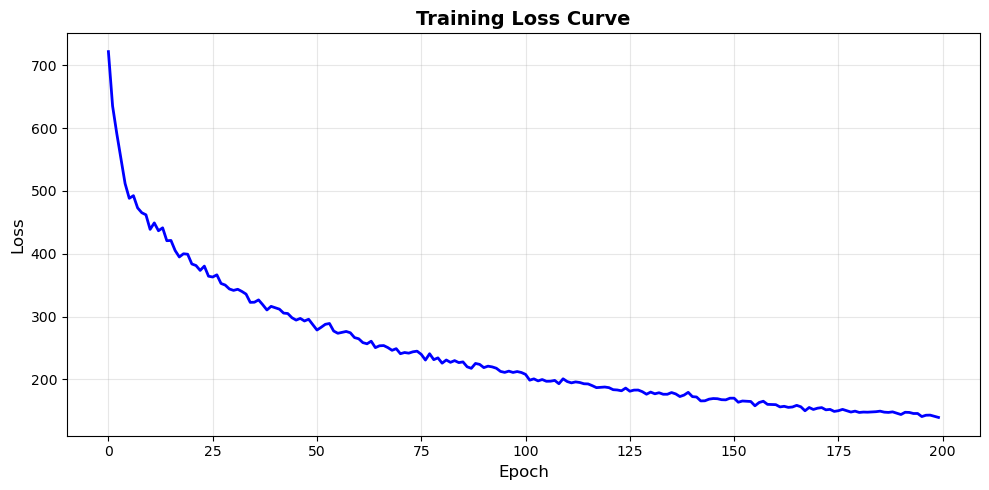

Final loss: 139.4182
Loss change (first to last epoch): 582.1706
✓ Loss is decreasing - training appears stable


In [11]:
# Plot training loss to diagnose convergence
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, linewidth=2, color='blue')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss change (first to last epoch): {losses[0] - losses[-1]:.4f}")
if losses[-1] > losses[-10]:
    print("⚠️  WARNING: Loss is increasing in recent epochs - model may not be converging well")
else:
    print("✓ Loss is decreasing - training appears stable")


ANOMALY DETECTION: Training Data Statistics
Training samples: 557
Mean log probability: -137.7061
Std log probability: 99.5371
Threshold (10th percentile): -312.6562
Threshold (anomaly score): 312.6562

CLASSIFYING TEST DATA

Total test samples: 298
  - Normal polymer samples (expected NORMAL): 243
  - Ambient microplastic samples (expected ANOMALY): 55

Predicted as ANOMALY: 184 (61.7%)
Predicted as NORMAL: 114 (38.3%)

CLASSIFICATION METRICS

Precision: 0.2717  (of predicted anomalies, how many are truly anomalous)
Recall:    0.9091  (of actual anomalies, how many were detected)
F1 Score:  0.4184

Full Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.45      0.61       243
     ANOMALY       0.27      0.91      0.42        55

    accuracy                           0.53       298
   macro avg       0.61      0.68      0.51       298
weighted avg       0.83      0.53      0.58       298

Confusion Matrix:
                  Pr

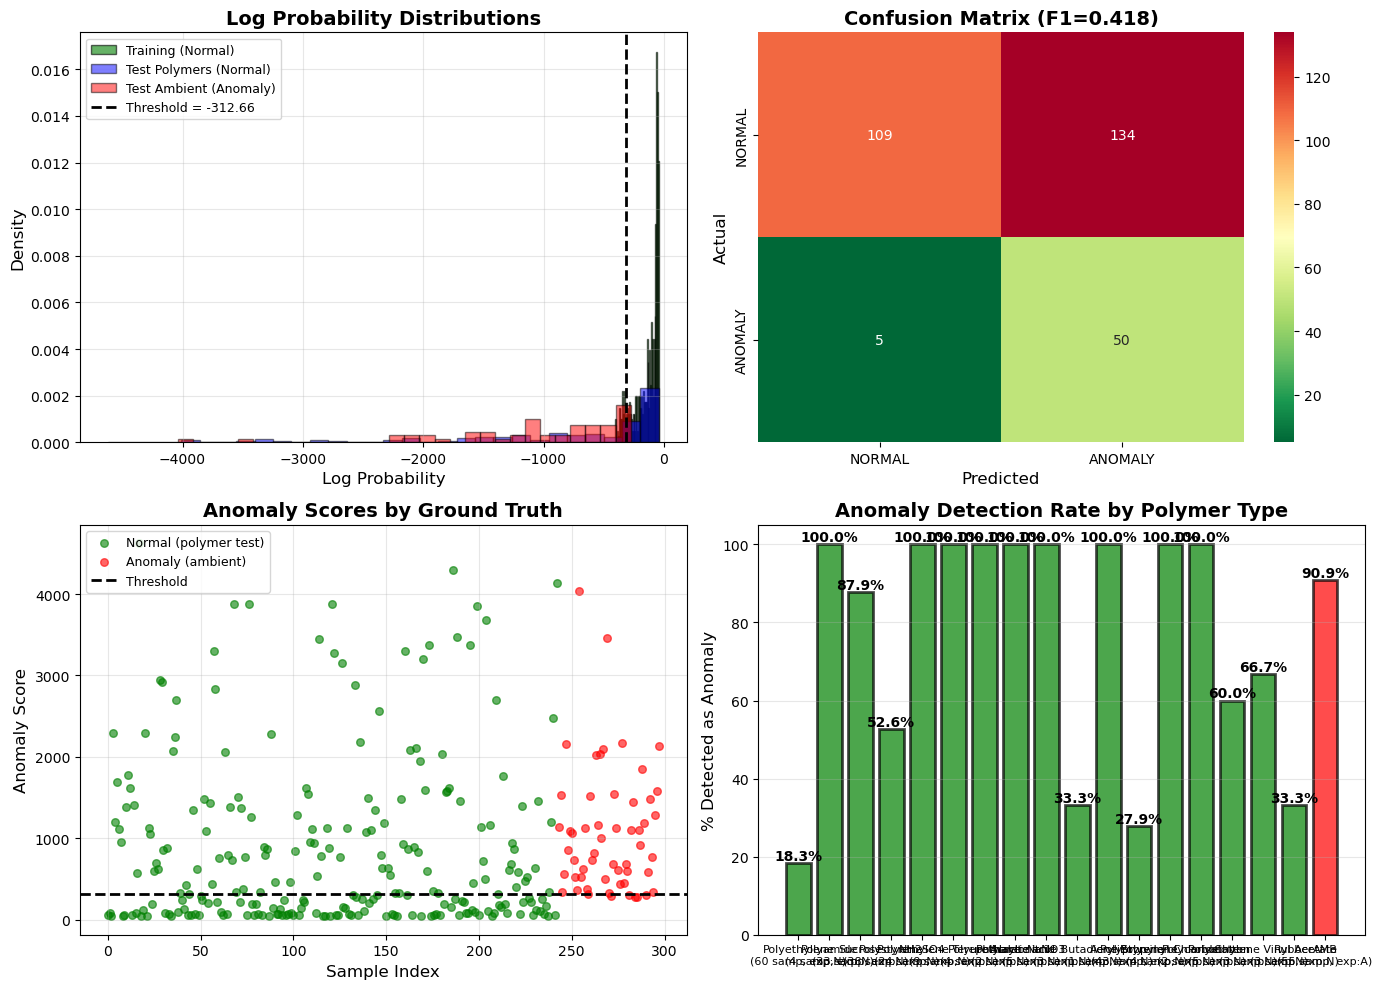


Results saved to: anomaly_detection_results.csv


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# ============================================================================
# EVALUATION: Classify test data as anomaly or normal
# Test set contains:
#   - df_polymer_test samples (NORMAL - known polymers held out from training)
#   - df_amb samples (ANOMALY - ambient microplastics)
# ============================================================================

model.eval()

# Step 1: Score TRAINING data to compute threshold
with torch.no_grad():
    train_log_probs = model(train_tensor).cpu().numpy()

# Compute threshold from training data statistics
THRESHOLD = 10
train_mean = train_log_probs.mean()
train_std = train_log_probs.std()
threshold_log_prob = np.percentile(train_log_probs, THRESHOLD)
threshold_anomaly_score = -threshold_log_prob

print(f"{'='*70}")
print(f"ANOMALY DETECTION: Training Data Statistics")
print(f"{'='*70}")
print(f"Training samples: {len(train_log_probs)}")
print(f"Mean log probability: {train_mean:.4f}")
print(f"Std log probability: {train_std:.4f}")
print(f"Threshold ({THRESHOLD}th percentile): {threshold_log_prob:.4f}")
print(f"Threshold (anomaly score): {threshold_anomaly_score:.4f}")

# Step 2: Score TEST data
print(f"\n{'='*70}")
print(f"CLASSIFYING TEST DATA")
print(f"{'='*70}\n")

with torch.no_grad():
    test_data = df_test.drop('polymer', axis=1).values
    if scaler is not None:
        test_scaled = scaler.transform(test_data)
    else:
        test_scaled = test_data.astype(np.float32)
    test_tensor = torch.FloatTensor(test_scaled)
    test_log_probs = model(test_tensor).cpu().numpy()

test_anomaly_scores = -test_log_probs
test_predictions = (test_anomaly_scores >= threshold_anomaly_score).astype(int)

# Step 3: Create ground truth labels
# Polymer test samples are NORMAL (0), ambient samples are ANOMALY (1)
n_polymer_test = len(df_polymer_test)
n_amb = len(df_amb)
ground_truth = np.array([0] * n_polymer_test + [1] * n_amb)

# Step 4: Create results dataframe
results_df = pd.DataFrame({
    'Sample_Index': range(len(test_log_probs)),
    'Log_Probability': test_log_probs.flatten(),
    'Anomaly_Score': test_anomaly_scores.flatten(),
    'Ground_Truth': ground_truth,
    'Predicted': test_predictions,
    'Ground_Truth_Label': ['ANOMALY' if g == 1 else 'NORMAL' for g in ground_truth],
    'Predicted_Label': ['ANOMALY' if p == 1 else 'NORMAL' for p in test_predictions]
})

if 'polymer' in df_test.columns:
    results_df['Polymer_Type'] = df_test['polymer'].values

# Display summary
anomaly_count = test_predictions.sum()
normal_count = len(test_predictions) - anomaly_count

print(f"Total test samples: {len(test_predictions)}")
print(f"  - Normal polymer samples (expected NORMAL): {n_polymer_test}")
print(f"  - Ambient microplastic samples (expected ANOMALY): {n_amb}")
print(f"\nPredicted as ANOMALY: {anomaly_count} ({100*anomaly_count/len(test_predictions):.1f}%)")
print(f"Predicted as NORMAL: {normal_count} ({100*normal_count/len(test_predictions):.1f}%)")

# Step 5: Compute proper metrics
print(f"\n{'='*70}")
print(f"CLASSIFICATION METRICS")
print(f"{'='*70}\n")

precision = precision_score(ground_truth, test_predictions, zero_division=0)
recall = recall_score(ground_truth, test_predictions, zero_division=0)
f1 = f1_score(ground_truth, test_predictions, zero_division=0)

print(f"Precision: {precision:.4f}  (of predicted anomalies, how many are truly anomalous)")
print(f"Recall:    {recall:.4f}  (of actual anomalies, how many were detected)")
print(f"F1 Score:  {f1:.4f}")

print(f"\nFull Classification Report:")
print(classification_report(ground_truth, test_predictions, target_names=['NORMAL', 'ANOMALY']))

cm = confusion_matrix(ground_truth, test_predictions)
print(f"Confusion Matrix:")
print(f"                  Predicted NORMAL  Predicted ANOMALY")
print(f"  Actual NORMAL   {cm[0,0]:>16}  {cm[0,1]:>17}")
print(f"  Actual ANOMALY  {cm[1,0]:>16}  {cm[1,1]:>17}")

# Step 6: Per-sample results
print(f"\n{'='*70}")
print(f"PER-SAMPLE RESULTS (first 20 samples)")
print(f"{'='*70}\n")
print(results_df.head(20).to_string(index=False))

if len(results_df) > 20:
    print(f"\n... and {len(results_df) - 20} more samples")

# Step 7: Per-polymer breakdown
if 'polymer' in df_test.columns:
    print(f"\n{'='*70}")
    print(f"RESULTS BY POLYMER TYPE")
    print(f"{'='*70}")
    
    for polymer in df_test['polymer'].unique():
        polymer_mask = results_df['Polymer_Type'] == polymer
        polymer_results = results_df[polymer_mask]
        
        anomaly_detected = polymer_results['Predicted'].sum()
        total = len(polymer_results)
        pct = 100 * anomaly_detected / total
        avg_anomaly_score = polymer_results['Anomaly_Score'].mean()
        expected = 'ANOMALY' if polymer_results['Ground_Truth'].iloc[0] == 1 else 'NORMAL'
        
        print(f"\n{polymer} (expected: {expected}):")
        print(f"  Total samples: {total}")
        print(f"  Detected as ANOMALY: {anomaly_detected}/{total} ({pct:.1f}%)")
        print(f"  Avg anomaly score: {avg_anomaly_score:.4f}")

# Step 8: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of log probabilities
ax = axes[0, 0]
ax.hist(train_log_probs, bins=50, alpha=0.6, label='Training (Normal)', 
        color='green', edgecolor='black', density=True)
# Separate test into polymer_test (normal) and ambient (anomaly)
polymer_test_log_probs = test_log_probs[:n_polymer_test]
amb_log_probs = test_log_probs[n_polymer_test:]
ax.hist(polymer_test_log_probs, bins=30, alpha=0.5, label='Test Polymers (Normal)', 
        color='blue', edgecolor='black', density=True)
ax.hist(amb_log_probs, bins=30, alpha=0.5, label='Test Ambient (Anomaly)', 
        color='red', edgecolor='black', density=True)
ax.axvline(threshold_log_prob, color='black', linestyle='--', linewidth=2, 
          label=f'Threshold = {threshold_log_prob:.2f}')
ax.set_xlabel('Log Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Log Probability Distributions', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 2: Confusion matrix heatmap
ax = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', 
            xticklabels=['NORMAL', 'ANOMALY'], yticklabels=['NORMAL', 'ANOMALY'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix (F1={f1:.3f})', fontsize=14, fontweight='bold')

# Plot 3: Anomaly scores scatter plot colored by ground truth
ax = axes[1, 0]
normal_mask = ground_truth == 0
anomaly_mask = ground_truth == 1
ax.scatter(np.where(normal_mask)[0], test_anomaly_scores[normal_mask], 
           c='green', alpha=0.6, s=30, label='Normal (polymer test)')
ax.scatter(np.where(anomaly_mask)[0], test_anomaly_scores[anomaly_mask], 
           c='red', alpha=0.6, s=30, label='Anomaly (ambient)')
ax.axhline(threshold_anomaly_score, color='black', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Anomaly Score', fontsize=12)
ax.set_title('Anomaly Scores by Ground Truth', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 4: Detection rates by polymer type
if 'polymer' in df_test.columns:
    ax = axes[1, 1]
    polymer_types = results_df['Polymer_Type'].unique()
    detection_rates = []
    labels_by_polymer = []
    bar_colors = []
    
    for polymer in polymer_types:
        polymer_mask = results_df['Polymer_Type'] == polymer
        polymer_results = results_df[polymer_mask]
        total = len(polymer_results)
        anomaly_detected = polymer_results['Predicted'].sum()
        detection_rates.append(100 * anomaly_detected / total)
        expected = 'A' if polymer_results['Ground_Truth'].iloc[0] == 1 else 'N'
        labels_by_polymer.append(f"{polymer}\n({total} samp, exp:{expected})")
        bar_colors.append('red' if expected == 'A' else 'green')
    
    bars = ax.bar(range(len(polymer_types)), detection_rates, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xticks(range(len(polymer_types)))
    ax.set_xticklabels(labels_by_polymer, fontsize=8)
    ax.set_ylabel('% Detected as Anomaly', fontsize=12)
    ax.set_title('Anomaly Detection Rate by Polymer Type', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, rate in zip(bars, detection_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{rate:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Step 9: Save results to CSV
output_filename = 'anomaly_detection_results.csv'
results_df.to_csv(output_filename, index=False)
print(f"\nResults saved to: {output_filename}")


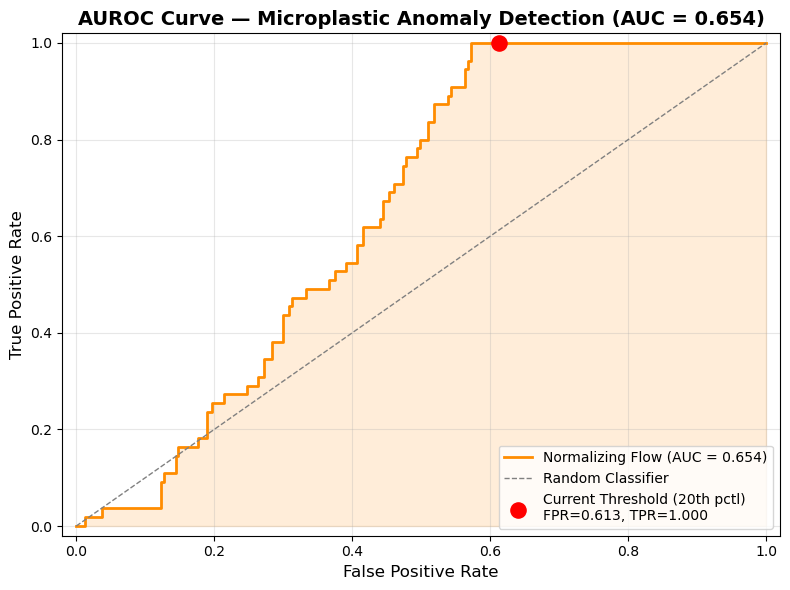

AUROC: 0.6539

MISCLASSIFICATION BREAKDOWN BY POLYMER TYPE

                        Polymer Expected  Total  Correct  Mislabeled Mislabeled %     Error Type
                            AMB  ANOMALY     55       55           0         0.0% False Negative
                        Sucrose   NORMAL     33        2          31        93.9% False Positive
                         NH2SO4   NORMAL     24        0          24       100.0% False Positive
                    Polystyrene   NORMAL     38       15          23        60.5% False Positive
                  Polypropylene   NORMAL     43       27          16        37.2% False Positive
                   Polyethylene   NORMAL     60       47          13        21.7% False Positive
     Polyethylene Terephthalate   NORMAL      9        0           9       100.0% False Positive
                          NaNO3   NORMAL      5        0           5       100.0% False Positive
                         Cotton   NORMAL      5        0           

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ============================================================================
# AUROC CURVE
# ============================================================================

fpr, tpr, thresholds = roc_curve(ground_truth, test_anomaly_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'Normalizing Flow (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.15, color='darkorange')

# Mark the operating point corresponding to the current threshold
current_fpr = cm[0, 1] / (cm[0, 0] + cm[0, 1])  # FP / (TN + FP)
current_tpr = cm[1, 1] / (cm[1, 0] + cm[1, 1])  # TP / (FN + TP)
ax.scatter([current_fpr], [current_tpr], color='red', s=120, zorder=5, 
           label=f'Current Threshold ({THRESHOLD}th pctl)\nFPR={current_fpr:.3f}, TPR={current_tpr:.3f}')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'AUROC Curve — Microplastic Anomaly Detection (AUC = {roc_auc:.3f})', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

print(f"AUROC: {roc_auc:.4f}")

# ============================================================================
# MISCLASSIFICATION TABLE BY POLYMER TYPE
# ============================================================================

print(f"\n{'='*90}")
print(f"MISCLASSIFICATION BREAKDOWN BY POLYMER TYPE")
print(f"{'='*90}\n")

misclass_data = []
for polymer in results_df['Polymer_Type'].unique():
    mask = results_df['Polymer_Type'] == polymer
    polymer_df = results_df[mask]
    total = len(polymer_df)
    expected_label = 'ANOMALY' if polymer_df['Ground_Truth'].iloc[0] == 1 else 'NORMAL'
    
    if expected_label == 'NORMAL':
        # Mislabeled = predicted as ANOMALY (false positives)
        mislabeled = polymer_df['Predicted'].sum()
        correct = total - mislabeled
        error_type = 'False Positive'
    else:
        # Mislabeled = predicted as NORMAL (false negatives)
        mislabeled = (polymer_df['Predicted'] == 0).sum()
        correct = total - mislabeled
        error_type = 'False Negative'
    
    misclass_data.append({
        'Polymer': polymer,
        'Expected': expected_label,
        'Total': total,
        'Correct': correct,
        'Mislabeled': mislabeled,
        'Mislabeled %': f"{100 * mislabeled / total:.1f}%",
        'Error Type': error_type
    })

misclass_table = pd.DataFrame(misclass_data)
misclass_table = misclass_table.sort_values(['Expected', 'Mislabeled'], ascending=[True, False])

# Summary row
total_all = misclass_table['Total'].sum()
mislabeled_all = misclass_table['Mislabeled'].sum()
summary = pd.DataFrame([{
    'Polymer': '--- TOTAL ---',
    'Expected': '',
    'Total': total_all,
    'Correct': total_all - mislabeled_all,
    'Mislabeled': mislabeled_all,
    'Mislabeled %': f"{100 * mislabeled_all / total_all:.1f}%",
    'Error Type': ''
}])
misclass_table = pd.concat([misclass_table, summary], ignore_index=True)

print(misclass_table.to_string(index=False))


## Hyperparameter Tuning Grid Search
Search over model architecture and training parameters, then rank configurations by AUROC and F1.

In [14]:
import itertools
import time
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, RobustScaler

# ============================================================================
# HYPERPARAMETER GRID — edit these to control what gets tested
# ============================================================================

param_grid = {
    'n_layers':    [4, 6, 8],            # depth of the flow
    'hidden_dim':  [64, 128, 256],        # width of coupling-layer MLPs
    'n_epochs':    [100, 200],            # training duration
    'batch_size':  [32, 64],              # mini-batch size
    'lr':          [1e-3, 5e-4, 1e-4],    # learning rate
    'scaler_type': ['standard'],          # 'standard' or 'robust'
    'threshold_pctl': [25],               # percentile threshold for anomaly cutoff
    'scale_factor':   [0.3],              # Tanh scale in AffineCouplingLayer
}

# Quick estimate
combos = list(itertools.product(*param_grid.values()))
print(f"Total configurations to test: {len(combos)}")
print(f"Parameters being varied:")
for k, v in param_grid.items():
    if len(v) > 1:
        print(f"  {k}: {v}")

Total configurations to test: 108
Parameters being varied:
  n_layers: [4, 6, 8]
  hidden_dim: [64, 128, 256]
  n_epochs: [100, 200]
  batch_size: [32, 64]
  lr: [0.001, 0.0005, 0.0001]


In [21]:
# ============================================================================
# RUN GRID SEARCH
# ============================================================================

# We need a modified AffineCouplingLayer that accepts scale_factor
class AffineCouplingLayerTunable(nn.Module):
    def __init__(self, dim, hidden_dim=64, scale_factor=0.3):
        super().__init__()
        self.dim = dim
        self.split_dim = dim // 2
        self.scale_factor = scale_factor

        self.scale_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim)),
            nn.Tanh()
        )
        self.shift_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim))
        )

    def forward(self, x):
        x1, x2 = x[:, :self.split_dim], x[:, self.split_dim:]
        s = self.scale_net(x1) * self.scale_factor
        t = self.shift_net(x1)
        y2 = x2 * torch.exp(s) + t
        log_det = s.sum(dim=1)
        return torch.cat([x1, y2], dim=1), log_det

    def inverse(self, y):
        y1, y2 = y[:, :self.split_dim], y[:, self.split_dim:]
        s = self.scale_net(y1) * self.scale_factor
        t = self.shift_net(y1)
        x2 = (y2 - t) * torch.exp(-s)
        return torch.cat([y1, x2], dim=1)


class NormalizingFlowTunable(nn.Module):
    def __init__(self, dim, n_layers=4, hidden_dim=64, scale_factor=0.3):
        super().__init__()
        self.dim = dim
        self.base_dist = StandardGaussian(dim)
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(AffineCouplingLayerTunable(dim, hidden_dim, scale_factor))
            if i < n_layers - 1:
                self.layers.append(PermutationLayer(dim))

    def forward(self, x):
        z = x
        log_det_sum = torch.zeros(x.shape[0], device=x.device)
        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det
        return self.base_dist.log_prob(z) + log_det_sum


def train_flow_silent(model, data, n_epochs, batch_size, lr):
    """Train without printing progress."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_batches = max(1, len(data) // batch_size)
    final_loss = None
    for epoch in range(n_epochs):
        perm = torch.randperm(len(data))
        data_shuffled = data[perm]
        epoch_loss = 0
        for i in range(n_batches):
            batch = data_shuffled[i * batch_size:(i + 1) * batch_size]
            optimizer.zero_grad()
            log_prob = model(batch)
            loss = -log_prob.mean()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        final_loss = epoch_loss / n_batches
    return final_loss


# Prepare data once
normal_data_grid = df_train.drop('polymer', axis=1).values
test_data_grid = df_test.drop('polymer', axis=1).values
n_polymer_test_grid = len(df_polymer_test)
n_amb_grid = len(df_amb)
ground_truth_grid = np.array([0] * n_polymer_test_grid + [1] * n_amb_grid)

results_list = []
keys = list(param_grid.keys())
total_runs = len(combos)

print(f"Starting grid search over {total_runs} configurations...\n")

for run_idx, values in enumerate(combos, 1):
    params = dict(zip(keys, values))

    # Scaler
    if params['scaler_type'] == 'robust':
        sc = RobustScaler()
    else:
        sc = StandardScaler()

    train_scaled = sc.fit_transform(normal_data_grid)
    test_scaled = sc.transform(test_data_grid)
    train_t = torch.FloatTensor(train_scaled)
    test_t = torch.FloatTensor(test_scaled)

    n_features = train_t.shape[1]

    # Build & train
    mdl = NormalizingFlowTunable(
        dim=n_features,
        n_layers=params['n_layers'],
        hidden_dim=params['hidden_dim'],
        scale_factor=params['scale_factor']
    )

    t0 = time.time()
    final_loss = train_flow_silent(
        mdl, train_t,
        n_epochs=params['n_epochs'],
        batch_size=params['batch_size'],
        lr=params['lr']
    )
    elapsed = time.time() - t0

    # Evaluate
    mdl.eval()
    with torch.no_grad():
        train_lp = mdl(train_t).cpu().numpy()
        test_lp = mdl(test_t).cpu().numpy()

    threshold_lp = np.percentile(train_lp, params['threshold_pctl'])
    test_scores = -test_lp
    threshold_score = -threshold_lp
    preds = (test_scores >= threshold_score).astype(int)

    prec = precision_score(ground_truth_grid, preds, zero_division=0)
    rec = recall_score(ground_truth_grid, preds, zero_division=0)
    f1 = f1_score(ground_truth_grid, preds, zero_division=0)

    fpr_arr, tpr_arr, _ = roc_curve(ground_truth_grid, test_scores)
    auroc = auc(fpr_arr, tpr_arr)

    cm = confusion_matrix(ground_truth_grid, preds)
    tn, fp, fn, tp = cm.ravel()

    result = {**params,
              'final_loss': round(final_loss, 4),
              'auroc': round(auroc, 4),
              'f1': round(f1, 4),
              'precision': round(prec, 4),
              'recall': round(rec, 4),
              'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
              'train_time_s': round(elapsed, 1)}
    results_list.append(result)

    print(f"[{run_idx}/{total_runs}] "
          f"layers={params['n_layers']} hdim={params['hidden_dim']} "
          f"ep={params['n_epochs']} bs={params['batch_size']} lr={params['lr']} "
          f"| AUROC={auroc:.3f}  F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}  "
          f"Loss={final_loss:.2f}  Time={elapsed:.0f}s")

tuning_df = pd.DataFrame(results_list)
print(f"\nGrid search complete — {len(tuning_df)} runs recorded.")

Starting grid search over 108 configurations...



KeyboardInterrupt: 

In [ ]:
# ============================================================================
# RESULTS — Ranked by AUROC then F1
# ============================================================================

# Sort and display top configurations
tuning_ranked = tuning_df.sort_values(['auroc', 'f1'], ascending=False).reset_index(drop=True)
tuning_ranked.index += 1  # 1-based rank
tuning_ranked.index.name = 'Rank'

# Show only the tuned columns + metrics for readability
varied_params = [k for k, v in param_grid.items() if len(v) > 1]
display_cols = varied_params + ['auroc', 'f1', 'precision', 'recall', 'final_loss', 'train_time_s']

print("=" * 90)
print("TOP 15 CONFIGURATIONS (ranked by AUROC → F1)")
print("=" * 90)
print(tuning_ranked[display_cols].head(15).to_string())

print(f"\n{'=' * 90}")
print("BEST CONFIGURATION")
print("=" * 90)
best = tuning_ranked.iloc[0]
for col in varied_params:
    print(f"  {col:>18s}: {best[col]}")
print(f"  {'AUROC':>18s}: {best['auroc']:.4f}")
print(f"  {'F1':>18s}: {best['f1']:.4f}")
print(f"  {'Precision':>18s}: {best['precision']:.4f}")
print(f"  {'Recall':>18s}: {best['recall']:.4f}")
print(f"  {'Final Loss':>18s}: {best['final_loss']:.4f}")
print(f"  {'Training Time (s)':>18s}: {best['train_time_s']:.1f}")

# Save full results table
tuning_ranked.to_csv('hyperparameter_tuning_results.csv')
print(f"\nFull results saved to: hyperparameter_tuning_results.csv")

# Save best model weights + scaler + params for reloading later
import pickle, json

torch.save(best_model_state, 'best_model_weights.pt')
print(f"Best model weights saved to: best_model_weights.pt")

with open('best_model_scaler.pkl', 'wb') as f:
    pickle.dump(best_scaler, f)
print(f"Best model scaler saved to: best_model_scaler.pkl")

with open('best_model_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)
print(f"Best model params saved to: best_model_params.json")

print(f"\n--- To reload the best model later ---")
print(f"  params = json.load(open('best_model_params.json'))")
print(f"  model = NormalizingFlowTunable(dim={n_features}, n_layers=params['n_layers'],")
print(f"          hidden_dim=params['hidden_dim'], scale_factor=params['scale_factor'])")
print(f"  model.load_state_dict(torch.load('best_model_weights.pt'))")
print(f"  scaler = pickle.load(open('best_model_scaler.pkl', 'rb'))")

NameError: name 'tuning_df' is not defined

In [ ]:
# ============================================================================
# VISUALIZE TUNING RESULTS
# ============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 — AUROC vs F1 scatter (each dot = one config)
ax = axes[0, 0]
sc_plot = ax.scatter(tuning_ranked['auroc'], tuning_ranked['f1'],
                     c=tuning_ranked['train_time_s'], cmap='viridis',
                     s=60, edgecolors='black', linewidth=0.5, alpha=0.8)
ax.set_xlabel('AUROC', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('AUROC vs F1 (color = training time)', fontsize=13, fontweight='bold')
plt.colorbar(sc_plot, ax=ax, label='Train time (s)')
ax.grid(alpha=0.3)

# 2 — AUROC by n_layers
ax = axes[0, 1]
if 'n_layers' in varied_params:
    for nl in sorted(tuning_df['n_layers'].unique()):
        subset = tuning_df[tuning_df['n_layers'] == nl]
        ax.scatter([nl] * len(subset), subset['auroc'], s=40, alpha=0.6, label=f'{nl} layers')
    ax.set_xlabel('n_layers', fontsize=12)
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title('AUROC by Number of Layers', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'n_layers not varied', transform=ax.transAxes, ha='center')

# 3 — AUROC by hidden_dim
ax = axes[1, 0]
if 'hidden_dim' in varied_params:
    for hd in sorted(tuning_df['hidden_dim'].unique()):
        subset = tuning_df[tuning_df['hidden_dim'] == hd]
        ax.scatter([hd] * len(subset), subset['auroc'], s=40, alpha=0.6, label=f'hdim={hd}')
    ax.set_xlabel('hidden_dim', fontsize=12)
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title('AUROC by Hidden Dimension', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'hidden_dim not varied', transform=ax.transAxes, ha='center')

# 4 — AUROC by learning rate
ax = axes[1, 1]
if 'lr' in varied_params:
    for lr_val in sorted(tuning_df['lr'].unique()):
        subset = tuning_df[tuning_df['lr'] == lr_val]
        ax.scatter([lr_val] * len(subset), subset['auroc'], s=40, alpha=0.6, label=f'lr={lr_val}')
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate (log scale)', fontsize=12)
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title('AUROC by Learning Rate', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'lr not varied', transform=ax.transAxes, ha='center')

plt.suptitle('Hyperparameter Tuning Results', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()